## 1. Dataset Overview & Data Quality

In [1]:
import pandas as pd

dictionary = pd.read_csv('../data/goodreads_data_dictionary.csv')
dictionary  # just display it — this is your field reference

,Table,Field,Description
0,works,work_id,Unique identifier for the book (work) in the d...
1,works,isbn,The 10-digit International Standard Book Numbe...
2,works,isbn13,The 13-digit International Standard Book Numbe...
3,works,original_title,"The original title of the book, in its origina..."
4,works,author,Name of the book’s primary author.
5,works,original_publication_year,Year the work was first published.
6,works,num_pages,Total number of pages in the work’s primary ed...
7,works,description,"Summary or synopsis of the book, typically fro..."
8,works,genres,Comma-separated list of genres associated with...
9,works,image_url,URL link to the book’s cover image.


**Observation:** the dictionary confirms `works` is one row per book with pre-aggregated rating counts (`5_star_ratings`...`1_star_ratings`, `ratings_count`, `avg_rating`), while `reviews` is one row per individual review. `work_id` is the shared key between the two tables.

In [2]:
works = pd.read_csv('../data/goodreads_works.csv')

print(works.shape)
works.head()

(13525, 20)


,work_id,isbn,isbn13,original_title,author,original_publication_year,num_pages,description,genres,image_url,reviews_count,text_reviews_count,5_star_ratings,4_star_ratings,3_star_ratings,2_star_ratings,1_star_ratings,ratings_count,avg_rating,similar_books
0,2919130,1416534601,9.781417e+12,Nocturnes,John Connolly,2004.0,NaN,NaN,"fiction, fantasy, paranormal, mystery, thrille...",https://s.gr-assets.com/assets/nophoto/book/11...,8820,338,1118,1601,1029,190,58,3996,3.9,NaN
1,52087333,NaN,NaN,Draw Play,Tia Lewis,2016.0,NaN,Jake:\nI can't believe my coach assigned me a ...,"romance, fiction",https://s.gr-assets.com/assets/nophoto/book/11...,2482,204,204,353,274,77,29,937,3.7,NaN
2,1649583,1416505520,9.781417e+12,Citizen of the Galaxy,Robert A. Heinlein,1957.0,NaN,"In a distant galaxy, the atrocity of slavery w...","fiction, young-adult, fantasy, paranormal, chi...",https://s.gr-assets.com/assets/nophoto/book/11...,16506,447,3539,4351,2863,444,53,11250,4.0,NaN
3,688299,0060541830,9.780061e+12,Congo,Michael Crichton,1980.0,NaN,"Deep in the African rain forest, near the lege...","fiction, mystery, thriller, crime, fantasy, pa...",https://s.gr-assets.com/assets/nophoto/book/11...,170916,1633,25081,45775,48505,14001,2926,136288,3.6,NaN
4,3464264,0451528824,9.780452e+12,Anne of Green Gables,L.M. Montgomery,1908.0,NaN,"Everyone's favorite redhead, the spunky Anne S...","fiction, young-adult, children, history, histo...",https://s.gr-assets.com/assets/nophoto/book/11...,743392,14586,272952,161856,81578,19933,9099,545418,4.2,NaN


**Observation:** 13,525 books, 20 columns. `original_publication_year` loads as `float64` (e.g. `2004.0`) rather than an int — will need casting before any year-based grouping or plotting.

In [3]:
works.dtypes

work_id                        int64
isbn                             str
isbn13                       float64
original_title                   str
author                           str
original_publication_year    float64
num_pages                    float64
description                      str
genres                           str
image_url                        str
reviews_count                  int64
text_reviews_count             int64
5_star_ratings                 int64
4_star_ratings                 int64
3_star_ratings                 int64
2_star_ratings                 int64
1_star_ratings                 int64
ratings_count                  int64
avg_rating                   float64
similar_books                    str
dtype: object

In [4]:
works.isnull().sum()

work_id                         0
isbn                         2051
isbn13                       1661
original_title                  0
author                          0
original_publication_year      18
num_pages                     730
description                   169
genres                          0
image_url                       0
reviews_count                   0
text_reviews_count              0
5_star_ratings                  0
4_star_ratings                  0
3_star_ratings                  0
2_star_ratings                  0
1_star_ratings                  0
ratings_count                   0
avg_rating                      0
similar_books                2515
dtype: int64

**Observation:** the columns that matter most for the five planned charts — `genres`, `author`, `avg_rating`, `ratings_count`, `reviews_count`, the per-star counts — have **zero** missing values. Gaps are concentrated in fields we don't currently plan to chart (`isbn`/`isbn13`, `num_pages`, `description`, `similar_books`), so missingness isn't a blocker for the chart plan.

In [5]:
works.duplicated().sum()

np.int64(0)

**Observation:** no duplicate rows in `works`.

In [6]:
reviews = pd.read_csv('../data/goodreads_reviews.csv')

print(reviews.shape)
reviews.head()
reviews.dtypes
reviews.isnull().sum()

/tmp/ipykernel_34308/1195728872.py:1: DtypeWarning: Columns (3: started_at) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv('../data/goodreads_reviews.csv')


(1143887, 10)


review_id           0
user_id             0
work_id             0
started_at     347495
read_at        112122
date_added          0
rating          37318
review_text         0
n_votes             0
n_comments          0
dtype: int64

**Observation:** 1,143,887 individual reviews. `rating` is missing on 37,318 rows (~3.3%) — these are text-only reviews with no star given, so any per-review rating analysis needs to drop or explicitly account for them. `started_at` triggered a mixed-dtype warning on load and has the most missing values (347,495) — it's the least reliable date field here. Given the file's size (881MB), full loads are workable but slow; may sample for iterative chart development.

In [7]:
works.columns
reviews.columns

Index(['review_id', 'user_id', 'work_id', 'started_at', 'read_at',
       'date_added', 'rating', 'review_text', 'n_votes', 'n_comments'],
      dtype='str')

In [8]:
works['work_id'].isin(reviews['work_id']).mean()  # adjust column name

np.float64(1.0)

**Observation:** every book in `works` has at least one matching review in `reviews` (join coverage = 1.0). Clean key, no orphaned books to worry about when merging the two tables.

## 2. Resolving open questions

Before locking metric definitions in Branch 2, four things need answers from the data itself rather than assumption.

### Q1 — is `author` single or multi-author per book?

In [9]:
multi_author = works[works['author'].str.contains(',', na=False)]
print(f"{len(multi_author)} / {len(works)} rows have a comma in author ({100*len(multi_author)/len(works):.2f}%)")
multi_author['author'].tolist()

1 / 13525 rows have a comma in author (0.01%)


['Garret Weyr, also Freymann-Weyr']

**Decision (Q1):** only 1 row out of 13,525 has a comma in `author` (`"Garret Weyr, also Freymann-Weyr"`, a pen-name annotation, not a co-author list). `author` is effectively single-author per book. **Chart 2 (author-level aggregation) can group directly on `author` with no name-splitting needed.**

### Q2 — is `genres` single or multi-genre per book?

In [10]:
genre_counts = works['genres'].str.split(',').apply(len)
print(genre_counts.describe())
print()
print("Pct of books with only 1 genre:", round(100 * (genre_counts == 1).mean(), 2))
print("Sample genres field:", works['genres'].iloc[0])

count    13525.000000
mean         5.869945
std          2.457028
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         23.000000
Name: genres, dtype: float64

Pct of books with only 1 genre: 1.33
Sample genres field: fiction, fantasy, paranormal, mystery, thriller, crime, young-adult


**Decision (Q2):** books have a median of 6 genre tags (range 1–23); only 1.3% are single-genre. Taking just the first listed genre as "primary" would discard most of the signal and the list order isn't documented as meaningful. **Chart 4 will explode `genres` into one row per (book, genre) pair** before aggregating median reviews per genre — meaning a single book contributes to multiple genre buckets. This will be called out explicitly in the chart's write-up so the genre totals aren't read as mutually exclusive.

### Q3 — should Chart 3 (controversy) use the `works` star-count buckets or raw `reviews.rating`?

In [11]:
import numpy as np

star_cols = ['1_star_ratings', '2_star_ratings', '3_star_ratings', '4_star_ratings', '5_star_ratings']
stars = np.array([1, 2, 3, 4, 5])

def weighted_std(row):
    counts = row[star_cols].values.astype(float)
    weights = counts / counts.sum()
    mean = (weights * stars).sum()
    return np.sqrt((weights * (stars - mean) ** 2).sum())

sample_std = works.head(5).apply(weighted_std, axis=1)
sample_std

0    0.919003
1    1.003609
2    0.876496
3    0.974137
4    0.945770
dtype: float64

**Decision (Q3): use the `works` star-count buckets, not raw `reviews.rating`.** Reasoning:
- `works` has the per-star counts for all 13,525 books with zero missing values, so a weighted std is computable for every book with no gaps.
- `reviews.rating` is missing on 3.3% of rows, and Chart 3 needs one variability score *per book* — using raw reviews would mean grouping 1.1M rows by `work_id` and handling the missing ratings within each group, for no real precision gain at this grain.
- The weighted-std approach above (binned across 1–5 stars) is a standard way to approximate rating spread from aggregate counts and is demonstrated on the first 5 books above.

**Chart 3 will plot `avg_rating` vs. this weighted std, computed from the star-count columns.**

### Q4 — what minimum-ratings threshold excludes low-sample noise for Chart 5 ("highly-rated authors" over time)?

In [12]:
print("ratings_count percentiles (book level):")
for p in [5, 10, 25, 50, 75, 90]:
    print(f"  p{p}: {works['ratings_count'].quantile(p/100):.0f}")

books_per_author = works.groupby('author').size()
print()
print("Books per author:")
print(books_per_author.describe())
print("Authors with only 1 book:", (books_per_author == 1).sum(), "/", len(books_per_author))

qualifying_books = works[works['ratings_count'] >= 1000]
qualifying_authors = qualifying_books.groupby('author').size()
print()
print("Authors with >=3 books at ratings_count >= 1000:", (qualifying_authors >= 3).sum())

ratings_count percentiles (book level):
  p5: 663
  p10: 1112
  p25: 2673
  p50: 7351
  p75: 22025
  p90: 65326

Books per author:
count    5554.000000
mean        2.435182
std         3.432484
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        53.000000
dtype: float64
Authors with only 1 book: 3340 / 5554

Authors with >=3 books at ratings_count >= 1000: 1228


**Decision (Q4): threshold = `ratings_count >= 1000` per book, plus `>= 3` qualifying books per author.**
- `ratings_count >= 1000` sits just above the p10 mark (1,112) — it drops the noisiest ~10% of long-tail books while keeping 12,349 / 13,525 books (91%) in play.
- Books-per-author is heavily skewed (median 1, 75th percentile 2), so most authors don't have enough books to plot a trend line at all. Requiring at least 3 qualifying books per author leaves 1,228 authors — enough to show genuine over-time patterns for Chart 5 without single-book noise driving the line.

## Branch 1 wrap-up

Both datasets are understood: `works` (13,525 books, book-level aggregates) and `reviews` (1.14M individual reviews), joined cleanly on `work_id`. All four open questions from the plan are now resolved with data-backed decisions:
1. `author` — single author per book, no splitting needed
2. `genres` — multi-genre (median 6/book); Chart 4 will explode to one row per (book, genre)
3. Chart 3 controversy metric — weighted std from `works` star-count buckets, not raw `reviews.rating`
4. Chart 5 threshold — `ratings_count >= 1000` and `>= 3` qualifying books per author

Ready to move to Branch 2 (`eda/analysis-definitions`) to lock these into concrete metric definitions and summary DataFrames.

## 3. Metric & Analysis Definitions

Before building summary DataFrames (Branch 3), lock down exactly what each chart measures. First question: `works` has both `reviews_count` and `ratings_count` — which one should stand in for "popularity"?

In [13]:
star_cols = ['1_star_ratings', '2_star_ratings', '3_star_ratings', '4_star_ratings', '5_star_ratings']
works['star_sum'] = works[star_cols].sum(axis=1)

print("ratings_count == sum(star cols)?", (works['ratings_count'] == works['star_sum']).mean())
print("reviews_count >= ratings_count for what pct of books?", (works['reviews_count'] >= works['ratings_count']).mean())
print()
print((works['reviews_count'] - works['ratings_count']).describe())

ratings_count == sum(star cols)? 1.0
reviews_count >= ratings_count for what pct of books? 0.9997042513863216

count    1.352500e+04
mean     2.522098e+04
std      6.085125e+04
min     -2.590550e+05
25%      3.462000e+03
50%      8.513000e+03
75%      2.124500e+04
max      1.155191e+06
dtype: float64


**Decision: `ratings_count` is the popularity metric used across all charts, not `reviews_count`.**
- `ratings_count` matches the sum of the five star-count columns exactly (100% of rows) — it's fully internally consistent and it's the same denominator already used in the Chart 3 weighted-std calculation, so using it everywhere keeps the definitions coherent.
- `reviews_count` runs higher on 99.97% of books (it includes text-only reviews with no star given), and on a small number of books it's actually *lower* than `ratings_count` (min diff of −259,055) — an unexplained inconsistency in the source data. Rather than build a headline metric on a field with an unresolved anomaly, `ratings_count` is the safer choice.

### Chart 1 — Most popular books (horizontal bar)
- **Metric:** `ratings_count`
- **Selection:** top 15 books by `ratings_count`, descending
- **Labels:** `original_title` (+ `author` where titles collide)

### Chart 2 — Author popularity: catalogue size vs. something more (scatter)
- **Grain:** one point per author (all 5,554 authors, no threshold — the whole point of this chart is to see whether small-catalogue authors can still break out)
- **X:** `book_count` = number of works per author
- **Y:** `total_ratings` = sum of `ratings_count` across an author's books
- Both computed by `groupby('author')` on the full `works` table

### Chart 3 — Controversial books: rating spread vs. average (scatter)
- **Metric:** `avg_rating` (x) vs. weighted std from star-count buckets (y), per the Q3 decision above
- **Filter:** `ratings_count >= 1000` (same floor as Q4) — below that, the weighted std is too noisy to call a book "controversial" with confidence
- Resulting base: 12,349 / 13,525 books

### Chart 4 — Genre engagement (horizontal bar)
- **Metric:** median `ratings_count` per genre
- **Grain:** `genres` exploded to one row per (book, genre) pair, per the Q2 decision — 16 distinct genres total, so no top-N cut needed, all 16 will be shown
- Median chosen over mean specifically because genre buckets are large and uneven in size (961 to 13,187 books) — mean would be dragged by outlier blockbusters

### Chart 5 — Do highly-rated authors sustain reception over time? (line)
- **Filter:** `ratings_count >= 1000` per book, `>= 3` qualifying books per author (Q4 decision) → 1,228 eligible authors, 7,859 qualifying books
- **Author selection:** top 10 authors by ratings-weighted average rating among the 1,228 eligible authors — "highly-rated" needs an explicit cutoff, and weighting by `ratings_count` prevents one obscure 3-book run from outranking an author with a genuinely large, consistently-loved catalogue
- **X:** `original_publication_year`, **Y:** `avg_rating`, one line per author

In [14]:
genres_exploded = works.assign(genre=works['genres'].str.split(',')).explode('genre')
genres_exploded['genre'] = genres_exploded['genre'].str.strip()
print("Distinct genres:", genres_exploded['genre'].nunique())
genres_exploded['genre'].value_counts()

Distinct genres: 16


genre
fiction               13187
romance                9255
fantasy                7407
paranormal             7407
mystery                6607
thriller               6607
crime                  6607
young-adult            6450
history                3954
historical fiction     3954
biography              3954
children               1297
comics                  961
graphic                 961
non-fiction             601
poetry                  182
Name: count, dtype: int64

In [15]:
qualifying = works[works['ratings_count'] >= 1000].copy()
author_book_counts = qualifying.groupby('author').size()
eligible_authors = author_book_counts[author_book_counts >= 3].index
chart5_base = qualifying[qualifying['author'].isin(eligible_authors)]

print("Eligible authors:", chart5_base['author'].nunique(), "| Qualifying books:", len(chart5_base))

weighted_avg = chart5_base.groupby('author').apply(
    lambda g: (g['avg_rating'] * g['ratings_count']).sum() / g['ratings_count'].sum(),
    include_groups=False
)
top10_authors = weighted_avg.sort_values(ascending=False).head(10)
top10_authors

Eligible authors: 1228 | Qualifying books: 7859


author
Patrick Rothfuss    4.537842
Francine Rivers     4.535852
Hiromu Arakawa      4.513754
J.K. Rowling        4.450272
Hajime Isayama      4.436836
Yana Toboso         4.432784
Bisco Hatori        4.426667
Sarah J. Maas       4.426485
Erin Hunter         4.422384
Hiro Mashima        4.412302
dtype: float64

## 4. Building Summary DataFrames

Four summary tables, one per chart grain, built directly from the locked definitions above.

### `book_summary` — grain: one row per book (Charts 1 & 3)

In [16]:
works['rating_std'] = works.apply(weighted_std, axis=1)

book_summary = works[[
    'work_id', 'original_title', 'author', 'original_publication_year',
    'genres', 'ratings_count', 'avg_rating', 'rating_std'
]].copy()

print(book_summary.shape)
book_summary.sort_values('ratings_count', ascending=False).head(3)

(13525, 8)


,work_id,original_title,author,original_publication_year,genres,ratings_count,avg_rating,rating_std
4368,2792775,The Hunger Games,Suzanne Collins,2008.0,"young-adult, fiction, fantasy, paranormal, rom...",5066596,4.3,0.87900
2627,4640799,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997.0,"fantasy, paranormal, young-adult, fiction, chi...",4972886,4.4,0.86698
2652,3212258,Twilight,Stephenie Meyer,2005.0,"young-adult, fantasy, paranormal, fiction, rom...",3992661,3.6,1.36295


**Observation:** `book_summary` holds all 13,525 books with `rating_std` computed for every one (no filtering yet — the `ratings_count >= 1000` cut from the Q4/Chart 3 decision gets applied at chart-build time in Branch 4, not baked into this table, so it stays reusable for both Chart 1 and Chart 3).

### `author_summary` — grain: one row per author (Chart 2)

In [17]:
author_summary = works.groupby('author').agg(
    book_count=('work_id', 'count'),
    total_ratings=('ratings_count', 'sum')
).reset_index()

print(author_summary.shape)
author_summary.sort_values('total_ratings', ascending=False).head(5)

(5554, 3)


,author,book_count,total_ratings
2097,J.K. Rowling,12,16814800
5117,Suzanne Collins,8,9310785
5036,Stephenie Meyer,8,8502945
5029,Stephen King,53,7797932
4500,Rick Riordan,24,5874480


**Observation:** 5,554 authors. J.K. Rowling tops `total_ratings` with only 12 books — a useful early signal for Chart 2 that catalogue size alone won't explain popularity, since plenty of authors have more books and far fewer total ratings.

### `genre_summary` — grain: one row per genre (Chart 4)

In [18]:
genres_exploded = works.assign(genre=works['genres'].str.split(',')).explode('genre')
genres_exploded['genre'] = genres_exploded['genre'].str.strip()

genre_summary = genres_exploded.groupby('genre').agg(
    median_ratings=('ratings_count', 'median'),
    book_count=('work_id', 'count')
).reset_index().sort_values('median_ratings', ascending=False)

genre_summary

,genre,median_ratings,book_count
10,non-fiction,17359.0,601
12,poetry,15378.5,182
1,children,9413.0,1297
0,biography,8125.0,3954
7,historical fiction,8125.0,3954
8,history,8125.0,3954
5,fiction,7508.0,13187
3,crime,7505.0,6607
14,thriller,7505.0,6607
9,mystery,7505.0,6607


**Observation:** `non-fiction` and `poetry` have the highest median `ratings_count` despite being the two smallest genre buckets (601 and 182 books) — small, curated categories can out-engage larger ones on a typical-book basis. `biography`, `historical fiction`, and `history` show an identical median (8,125) and identical book count (3,954), which is expected given how heavily those three tags co-occur on the same books in this dataset, not a coincidence to read into.

### `author_year_summary` — grain: one row per (book, author, year), filtered to the Chart 5 population

In [19]:
qualifying = book_summary[book_summary['ratings_count'] >= 1000].copy()
eligible_authors = qualifying.groupby('author').size()
eligible_authors = eligible_authors[eligible_authors >= 3].index

author_year_summary = qualifying[qualifying['author'].isin(eligible_authors)].copy()
print("Before dropping missing years:", author_year_summary.shape)
print("Missing original_publication_year:", author_year_summary['original_publication_year'].isnull().sum())

author_year_summary = author_year_summary.dropna(subset=['original_publication_year'])
author_year_summary['original_publication_year'] = author_year_summary['original_publication_year'].astype(int)

print("Final shape:", author_year_summary.shape, "| authors:", author_year_summary['author'].nunique())
author_year_summary.head(3)

Before dropping missing years: (7859, 8)
Missing original_publication_year: 5
Final shape: (7854, 8) | authors: 1228


,work_id,original_title,author,original_publication_year,genres,ratings_count,avg_rating,rating_std
0,2919130,Nocturnes,John Connolly,2004,"fiction, fantasy, paranormal, mystery, thrille...",3996,3.9,0.919003
2,1649583,Citizen of the Galaxy,Robert A. Heinlein,1957,"fiction, young-adult, fantasy, paranormal, chi...",11250,4.0,0.876496
3,688299,Congo,Michael Crichton,1980,"fiction, mystery, thriller, crime, fantasy, pa...",136288,3.6,0.974137


**Observation:** only 5 of 7,859 qualifying rows had a missing `original_publication_year`; dropping them cost 0 authors (all 1,228 eligible authors still have at least 3 dated books each). Final base: 7,854 rows across 1,228 authors, ready to filter down to the top 10 by weighted rating for the actual Chart 5 plot in Branch 4.

## Branch 3 wrap-up

Four summary DataFrames are built, each matching the grain and filters locked in Branch 2:
- `book_summary` (13,525 rows) — Charts 1 & 3
- `author_summary` (5,554 rows) — Chart 2
- `genre_summary` (16 rows) — Chart 4
- `author_year_summary` (7,854 rows, 1,228 authors) — Chart 5

No chart-specific top-N cuts (top 15 books, top 10 authors) are applied here — those stay in Branch 4 so these summaries remain reusable building blocks rather than one-off chart inputs.

## 5. Visualizations

Five charts, one per question from the plan, built from the four summary tables above. Color choices follow a validated palette: a single blue (`#2a78d6`) for every single-series chart (1–4), and an 8-color categorical order (validated for colorblind-safe adjacent placement — the arrangement bars/lines actually use) for Chart 5's multiple author lines. Since this is a static notebook export rather than an interactive page, hover tooltips don't apply here — selective direct labels on the notable points do that job instead.

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb',
    'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e',
    'text.color': '#0b0b0b',
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'grid.color': '#e5e4de',
    'grid.linewidth': 0.8,
    'font.size': 11,
})

BLUE = '#2a78d6'
CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

def strip_spines(ax, keep=('bottom',)):
    for side, spine in ax.spines.items():
        spine.set_visible(side in keep)
    ax.set_axisbelow(True)

### Chart 1 — Which books are most popular?

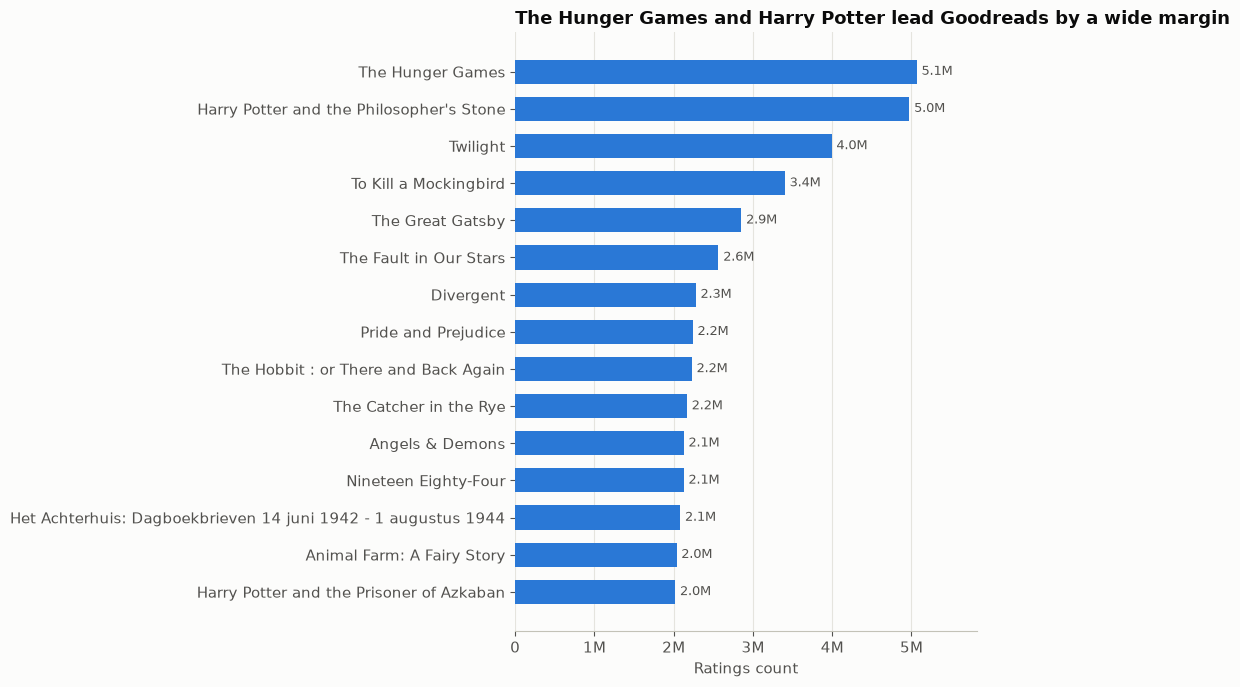

In [21]:
top15 = book_summary.sort_values('ratings_count', ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['original_title'], top15['ratings_count'], color=BLUE, height=0.65)

for bar, value in zip(bars, top15['ratings_count']):
    label = f'{value/1e6:.1f}M' if value >= 1e6 else f'{value:,}'
    ax.text(bar.get_width() + 60000, bar.get_y() + bar.get_height() / 2, label,
             va='center', ha='left', fontsize=9, color='#52514e')

ax.set_xlabel('Ratings count')
ax.set_title('The Hunger Games and Harry Potter lead Goodreads by a wide margin',
              fontsize=13, fontweight='bold', loc='left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{int(x):,}'))
ax.xaxis.grid(True)
ax.yaxis.grid(False)
strip_spines(ax, keep=('bottom',))
ax.set_xlim(0, top15['ratings_count'].max() * 1.15)
plt.tight_layout()
plt.show()

**Finding:** *The Hunger Games* (5,066,596 ratings) and *Harry Potter and the Philosopher's Stone* (4,972,886) lead by a clear margin — over a million ratings ahead of third-place *Twilight* (3,992,661). The top 15 skews heavily toward YA/crossover fiction (5 of the top 6), but long-standing classics like *To Kill a Mockingbird*, *1984*, and *Pride and Prejudice* still place inside the top 12 — likely reflecting decades of accumulated ratings rather than a recent surge, a distinction raw `ratings_count` can't separate out on its own.

### Chart 2 — Is author popularity just catalogue size, or something more?

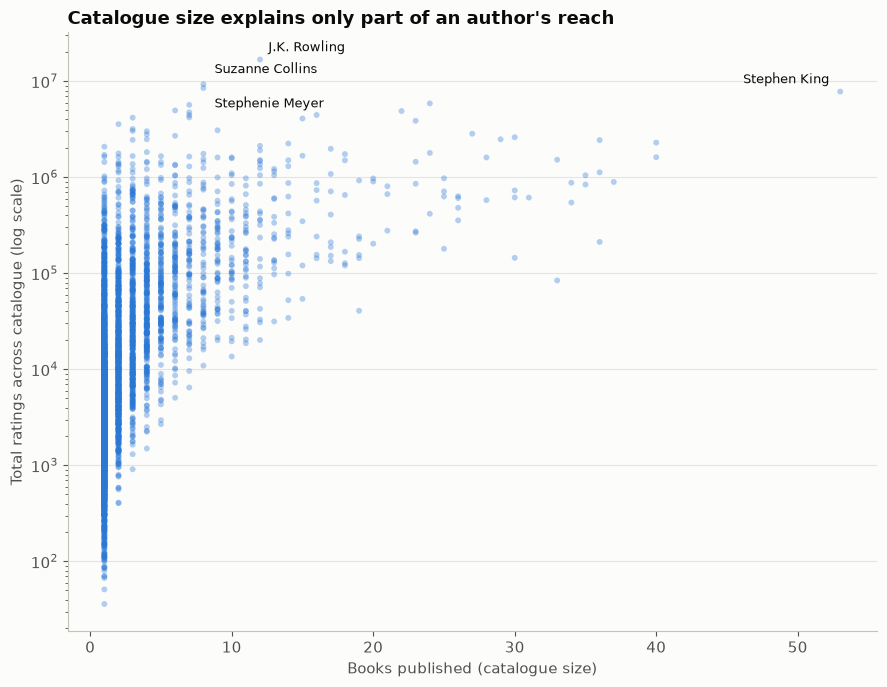

Correlation (book_count, total_ratings): 0.398


In [22]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(author_summary['book_count'], author_summary['total_ratings'],
           s=18, color=BLUE, alpha=0.35, edgecolors='none')

standout_offsets = {
    'J.K. Rowling': (6, 6),
    'Stephen King': (-8, 6),
    'Suzanne Collins': (8, 8),
    'Stephenie Meyer': (8, -14),
}
for name, offset in standout_offsets.items():
    row = author_summary.loc[author_summary['author'] == name].iloc[0]
    ha = 'right' if offset[0] < 0 else 'left'
    ax.annotate(name, (row['book_count'], row['total_ratings']),
                textcoords='offset points', xytext=offset, fontsize=9, color='#0b0b0b', ha=ha)

ax.set_yscale('log')
ax.set_xlabel('Books published (catalogue size)')
ax.set_ylabel('Total ratings across catalogue (log scale)')
ax.set_title("Catalogue size explains only part of an author's reach",
              fontsize=13, fontweight='bold', loc='left')
ax.yaxis.grid(True)
ax.xaxis.grid(False)
strip_spines(ax, keep=('bottom', 'left'))
plt.tight_layout()
plt.show()

print('Correlation (book_count, total_ratings):', round(author_summary['book_count'].corr(author_summary['total_ratings']), 3))

**Finding:** the correlation between catalogue size and total ratings is only 0.398 — moderate at best, not the dominant driver the chart title's question implies it might be. The clearest illustration is J.K. Rowling vs. Stephen King: Rowling's 12 books pull 16,814,800 total ratings, while King's 53 books — more than four times the catalogue — pull only 7,797,932, less than half. Reach is driven far more by how well individual books land than by how many an author publishes.

### Chart 3 — Which books generate disagreement, not just low ratings?

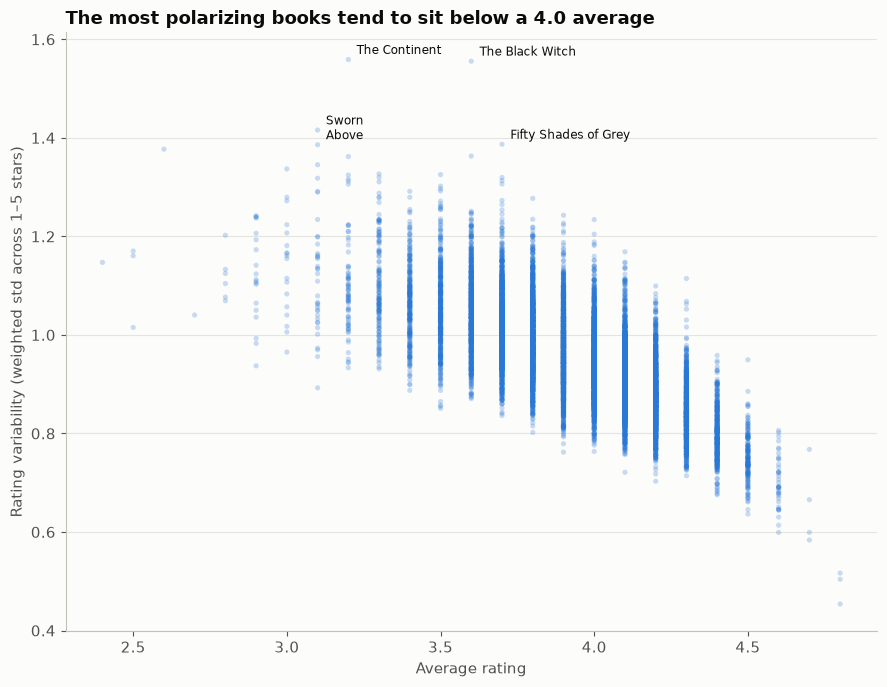

Correlation (avg_rating, rating_std): -0.708
Base: 12349 / 13525 books (ratings_count >= 1000)


In [23]:
qual = book_summary[book_summary['ratings_count'] >= 1000]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(qual['avg_rating'], qual['rating_std'], s=14, color=BLUE, alpha=0.25, edgecolors='none')

top_controversial = qual.sort_values('rating_std', ascending=False).head(5)
for _, row in top_controversial.iterrows():
    ax.annotate(row['original_title'], (row['avg_rating'], row['rating_std']),
                textcoords='offset points', xytext=(6, 4), fontsize=8.5, color='#0b0b0b')

ax.set_xlabel('Average rating')
ax.set_ylabel('Rating variability (weighted std across 1–5 stars)')
ax.set_title('The most polarizing books tend to sit below a 4.0 average',
              fontsize=13, fontweight='bold', loc='left')
ax.yaxis.grid(True)
ax.xaxis.grid(False)
strip_spines(ax, keep=('bottom', 'left'))
plt.tight_layout()
plt.show()

print('Correlation (avg_rating, rating_std):', round(qual['avg_rating'].corr(qual['rating_std']), 3))
print('Base:', len(qual), '/', len(book_summary), 'books (ratings_count >= 1000)')

**Finding:** average rating and rating variability are strongly negatively correlated (−0.708, on the 12,349-book filtered base) — books readers disagree on tend to also average lower, not just spread wider around a good score. The top 5 most polarizing books are mostly lower-profile titles (*The Continent*, *The Black Witch*, *Sworn*, *Above*), but one mainstream bestseller breaks the pattern: *Fifty Shades of Grey* sits at #4 with a 3.7 average and 1,448,482 ratings — proof that a book can be simultaneously wildly popular and genuinely divisive, not just a niche effect.

### Chart 4 — Which genres have the strongest typical engagement?

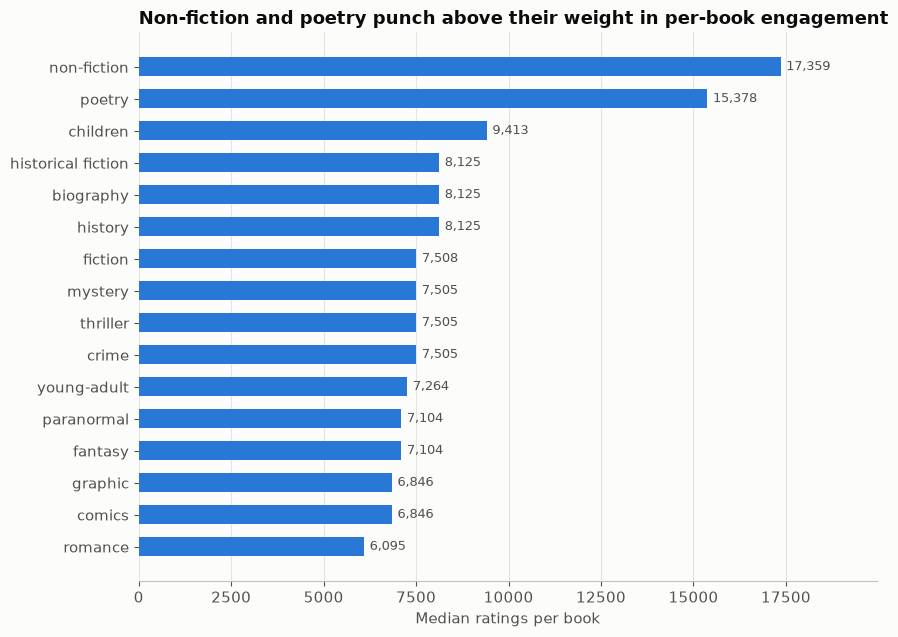

In [24]:
genre_plot = genre_summary.sort_values('median_ratings')

fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.barh(genre_plot['genre'], genre_plot['median_ratings'], color=BLUE, height=0.6)

for bar, value in zip(bars, genre_plot['median_ratings']):
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height() / 2, f'{value:,.0f}',
             va='center', fontsize=9, color='#52514e')

ax.set_xlabel('Median ratings per book')
ax.set_title('Non-fiction and poetry punch above their weight in per-book engagement',
              fontsize=13, fontweight='bold', loc='left')
ax.xaxis.grid(True)
ax.yaxis.grid(False)
strip_spines(ax, keep=('bottom',))
ax.set_xlim(0, genre_plot['median_ratings'].max() * 1.15)
plt.tight_layout()
plt.show()

**Finding:** `non-fiction` (median 17,359 ratings/book) and `poetry` (15,378) lead despite being the two smallest genre tags in the dataset (601 and 182 books respectively) — the typical book in these categories reaches more readers than the typical book in much larger genres like `romance` (6,095, the lowest of the 16). Note `biography`, `historical fiction`, and `history` share an identical median and book count (per the Branch 3 observation) because those tags heavily co-occur on the same books in this dataset — they aren't three independent data points here.

### Chart 5 — Do highly-rated authors sustain reception over time?

**Refinement to the Branch 2 decision:** that branch selected the top 10 authors by weighted average rating. For a line chart with a legend, 10 distinguishable colorblind-safe hues isn't achievable — the validated categorical palette clears its safety checks for **8** series in a legend/line context, not 10 (a 9th or 10th line would either repeat a hue or fall back to an unvalidated, potentially indistinguishable color). Selection narrows to the **top 8** here; the underlying `author_year_summary` table and threshold are unchanged.

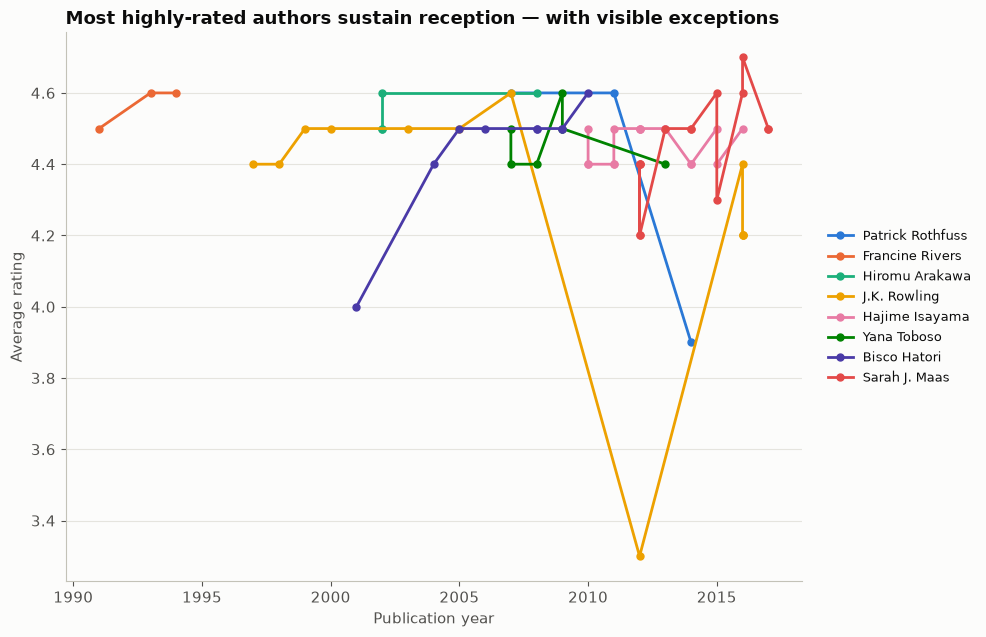

In [25]:
weighted_avg = author_year_summary.groupby('author').apply(
    lambda g: (g['avg_rating'] * g['ratings_count']).sum() / g['ratings_count'].sum(),
    include_groups=False
)
top8_authors = weighted_avg.sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(10, 6.5))
for color, author in zip(CATEGORICAL, top8_authors.index):
    sub = author_year_summary[author_year_summary['author'] == author].sort_values('original_publication_year')
    ax.plot(sub['original_publication_year'], sub['avg_rating'],
            color=color, linewidth=2, marker='o', markersize=5, label=author)

ax.set_xlabel('Publication year')
ax.set_ylabel('Average rating')
ax.set_title('Most highly-rated authors sustain reception — with visible exceptions',
              fontsize=13, fontweight='bold', loc='left')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
ax.yaxis.grid(True)
ax.xaxis.grid(False)
strip_spines(ax, keep=('bottom', 'left'))
plt.tight_layout()
plt.show()

**Finding:** 7 of the 8 authors hold a tight 4.2–4.7 band across every publication year in their qualifying catalogue — genuinely sustained reception, not a fluke of the selection. J.K. Rowling is the one visible exception: her Harry Potter run sits at 4.4–4.6 through 2007, then drops to 3.3 for *The Casual Vacancy* (2012) — her first adult-fiction title — before recovering to 4.2–4.4 for the Cormoran Strike novels (2016). The dip lines up with a genre/audience change, not a general decline.

One caveat worth stating plainly: these 8 authors were *selected* for having a high weighted average rating, so "most of them stay high" is partly true by construction. The more informative part of this finding is that they stay high with little year-to-year drift — the Rowling dip is the exception that shows what a genuine reception break looks like against that otherwise flat baseline.

## Branch 4 wrap-up

All five charts are built, each backed by the exact metrics and filters locked in Branch 2, and each finding cites specific numbers rather than a general impression. One refinement was made and documented in place: Chart 5's author count moved from 10 (Branch 2) to 8, to stay within the accessibility-validated categorical palette for a legend-based line chart. Ready for Branch 5 (`docs/data-story`) to turn these five findings into the half-page narrative.